In [1]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath("../"))
from utils.gref_pipeline.georef import *

sys.path.append(os.path.abspath("../../"))
from gref_pipeline import config

In [2]:
transect = load_transect(config.OUTPUT_FOLDER)
transect.list_files()


📋 Files in output (corrected=False):
 1. rad_uhi_20241029_115057_1  | shape=(1333, 968, 210)  | has_georef=True
 2. rad_uhi_20241029_115057_2  | shape=(1946, 968, 210)  | has_georef=True
 3. rad_uhi_20241029_115057_3  | shape=(2227, 968, 210)  | has_georef=True
 4. rad_uhi_20241029_115057_4  | shape=(2463, 968, 210)  | has_georef=True
 5. rad_uhi_20241029_115057_5  | shape=(2462, 968, 210)  | has_georef=True
 6. rad_uhi_20241029_115057_6  | shape=(155, 968, 210)  | has_georef=True


In [3]:
cube = transect.select_files(
    [
        # "rad_uhi_20241029_115057_4",
        "rad_uhi_20241029_115057_5",
    ]
)
cube.describe()

🔄 Rebuilding grids from georef hits for selected files...
   • rad_uhi_20241029_115057_5
  rad_uhi_20241029_115057_5: Using GRIDDED format (T=2462, S=968)
✅ Combined shapes: X/Y/Z (2462, 968), RGB (2462, 968)
🔄 Loading full hyperspectral cube...
   • Loading rad_uhi_20241029_115057_5...
✅ Loaded full cube: (2462, 968, 210) (T × S × B)

=== Combined_output ===
Tracks × Slits: 2462 × 968
RGB coverage: R/G/B finite ratios 1.00/1.00/1.00

📋 File boundaries:
  rad_uhi_20241029_115057_5: tracks 0–2461 (2462)


In [4]:
cube.list_saved_corrections()


📋 Cached illumination corrections:

📁 File: rad_uhi_20241029_115057_5
   ✓ window=1000, strength=1.0
     Dataset: dataCube_illum_corrected_w1000_s1p00
     Shape: (2462, 968, 210), Size: 1909.2 MB
   ✓ window=500, strength=1.0
     Dataset: dataCube_illum_corrected_w500_s1p00
     Shape: (2462, 968, 210), Size: 1909.2 MB


In [5]:
# Apply illumination correction with rolling window (window_size=1000 tracks)
# NOTE: Using V2 version (pandas rolling median, no scipy bugs)
# This will be cached to disk - next time it will load instantly!
# Use force_recompute=True to force recalculation
cube.apply_illumination_correction_v2(window_size=500, force_recompute=False)

🔄 Using V2 algorithm (pandas rolling median)
✅ Illumination correction already applied with window=500, strength=1.0
   Loading from disk...
📂 Loading saved illumination correction from 1 files...
   rad_uhi_20241029_115057_5: window=500, strength=1.0
✅ Loaded illumination correction from disk


array([[[2.2304249e+00, 1.6764377e+00, 0.0000000e+00, ...,
         0.0000000e+00, 7.0077596e+00, 0.0000000e+00],
        [7.4757171e+00, 8.5974735e-01, 0.0000000e+00, ...,
         0.0000000e+00, 3.0958059e+00, 0.0000000e+00],
        [1.8294926e+00, 2.3438740e+00, 0.0000000e+00, ...,
         0.0000000e+00, 7.1090145e+00, 0.0000000e+00],
        ...,
        [1.7213115e+00, 1.4317783e+00, 0.0000000e+00, ...,
         1.0000000e+00, 2.3279436e-02, 3.7040919e-01],
        [5.8812752e+00, 2.0123754e+00, 0.0000000e+00, ...,
         0.0000000e+00, 1.4956644e+00, 0.0000000e+00],
        [2.3867478e+00, 1.0000000e+00, 0.0000000e+00, ...,
         0.0000000e+00, 1.5736811e+01, 4.5105180e-01]],

       [[2.2304249e+00, 7.7452070e-01, 3.9940205e+00, ...,
         0.0000000e+00, 0.0000000e+00, 9.6023534e-05],
        [1.7471981e+00, 0.0000000e+00, 1.2654871e+00, ...,
         0.0000000e+00, 8.5029960e-01, 6.3767982e-01],
        [1.9216584e+00, 0.0000000e+00, 3.0771544e+00, ...,
         0.000

In [6]:
cube.adjust_uhi_alignment(dx=-0.05, dy=-3.0)

✅ UHI alignment adjusted:
   dx (East):  -0.050 m
   dy (North): -3.000 m

💡 This will be applied in plot_georef() with coordinate_system='NED'


In [7]:
# Import ROIs from file
cube.import_rois("my_rois.json")

📂 Imported 11 ROIs from my_rois.json


In [8]:
# List all ROIs
cube.list_rois()


📂 ROI Collection (11 ROIs):
 1. 'sed1': 273 pixels
     Slit range:   14 - 870
     Track range: 577 - 1580
 2. 'dark1': 98 pixels
     Slit range:  606 - 740
     Track range: 729 - 765
 3. 'dark2': 140 pixels
     Slit range:  174 - 356
     Track range: 1094 - 1148
 4. 'dark_collected': 68 pixels
     Slit range:  177 - 736
     Track range: 733 - 1149
 5. 'vertical': 62 pixels
     Slit range:  224 - 404
     Track range: 1124 - 1168
 6. 'vertical_inside': 82 pixels
     Slit range:  244 - 291
     Track range: 1126 - 1135
 7. 'tripple': 71 pixels
     Slit range:  662 - 701
     Track range: 593 - 598
 8. 'tripple2': 42 pixels
     Slit range:  639 - 654
     Track range: 700 - 705
 9. 'tripple3': 84 pixels
     Slit range:  632 - 678
     Track range: 757 - 765
10. 'double1': 114 pixels
     Slit range:  809 - 880
     Track range: 1500 - 1516
11. 'double2': 61 pixels
     Slit range:  659 - 690
     Track range: 1540 - 1547


In [9]:
# Example: Combine multiple ROIs
# cube.combine_rois(roi_names_to_combine=["sed1", "sed2"], new_roi_name="all_sediment")

In [10]:
cube.rename_roi(old_roi_name="sed1", new_roi_name="Sediment")

✅ Renamed ROI 'sed1' → 'Sediment' (273 pixels)


True

💡 Interactive mode: Click on the plot to display coordinates


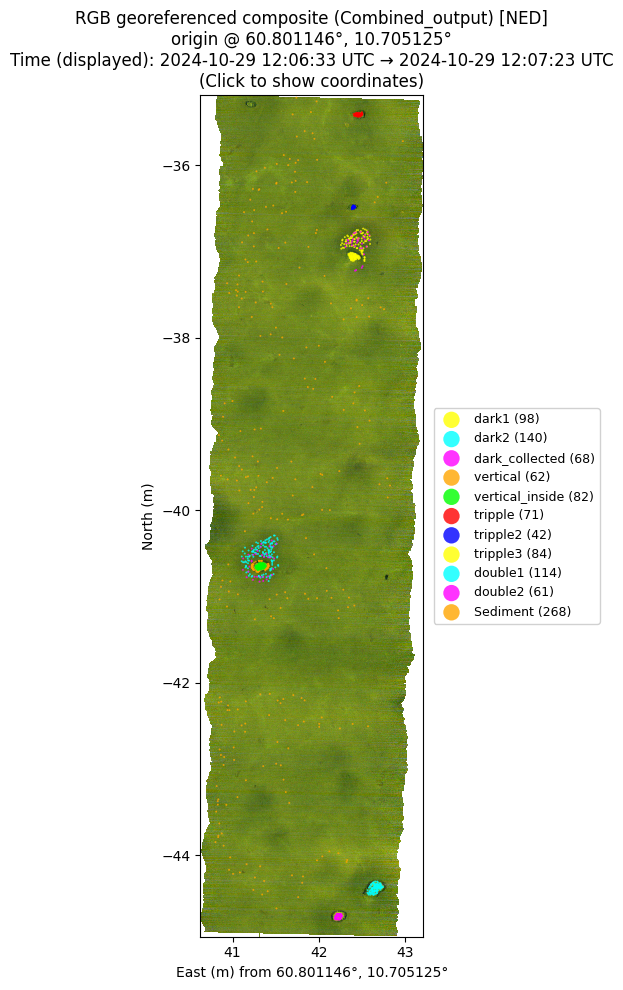

In [11]:
cube.plot_georef(
    apply_alignment_shift=True,
    use_corrected=True,
    coordinate_system="NED",
    track_start=config.UHI_TRACK_RANGE_5[0],
    track_end=config.UHI_TRACK_RANGE_5[1],
    figsize=(30, 10),
    roi_collection="all",
    roi_marker_size=2,
    roi_legend_loc="outside",
    roi_marker_edgewidth=0,
    roi_legend_markersize=50,
)

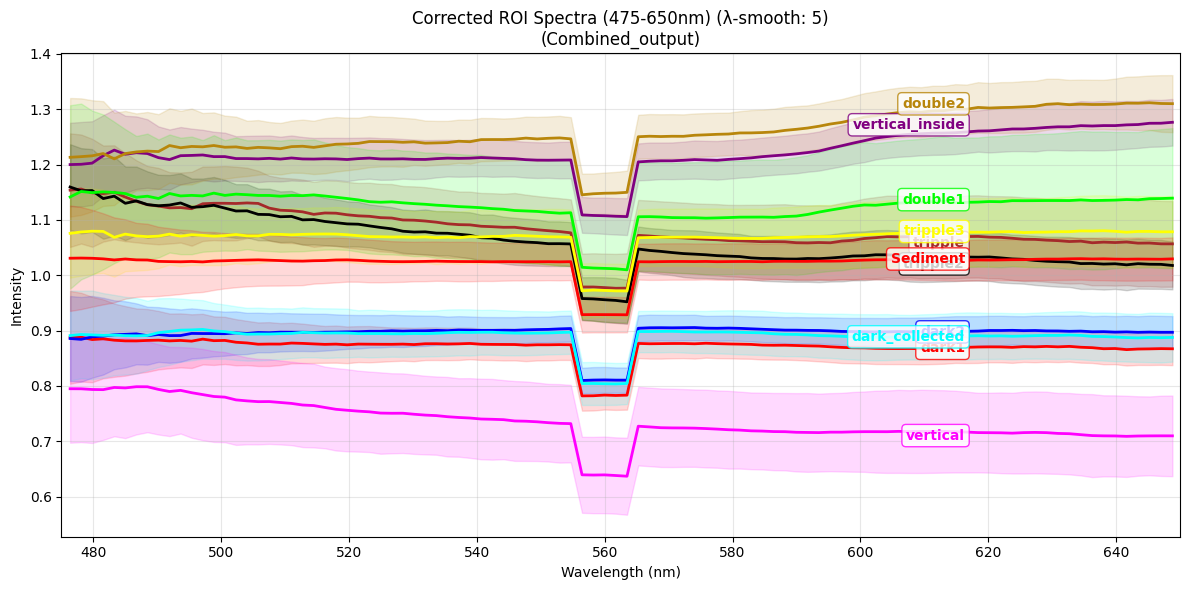

In [12]:
# All ROI spectra with std bands
cube.plot_spectrum(
    roi_names="all",
    use_corrected=True,
    wavelength_range=(475, 650),
    wavelength_smoothing=5,
)

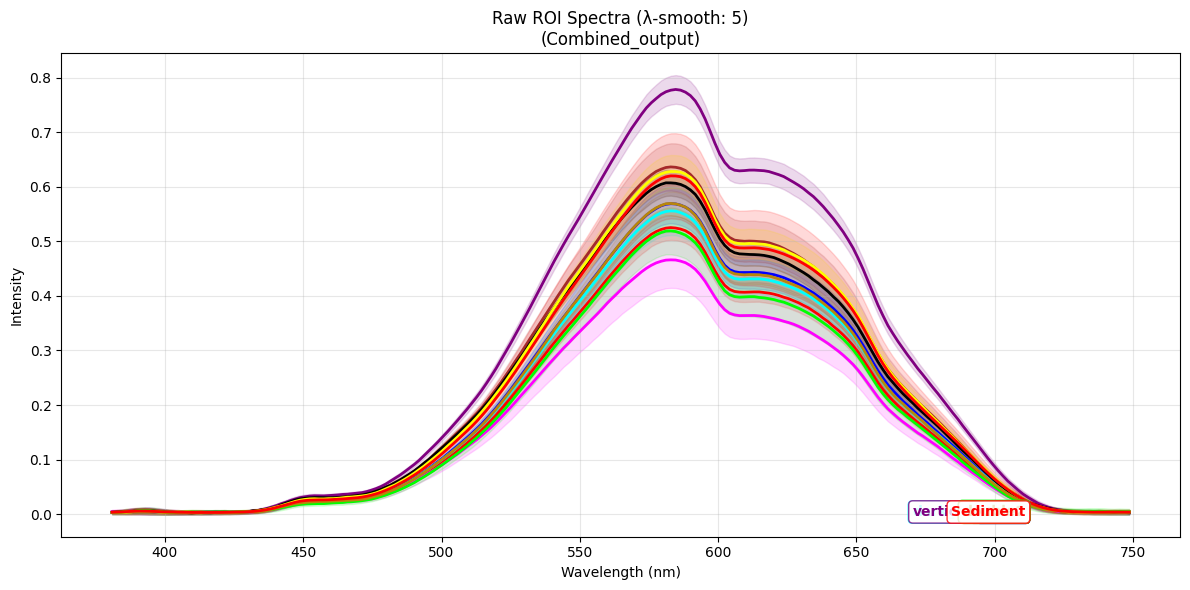

In [13]:
# All ROI spectra with std bands
cube.plot_spectrum(
    roi_names="all",
    use_corrected=False,
    # wavelength_range=(475, 650),
    wavelength_smoothing=5,
)

In [14]:
# Debug: Check wavelength 104 (~560nm) in the corrected data
import numpy as np

wl_idx = 104  # The problematic wavelength
test_roi_name = list(cube.roi_collection.keys())[0]
test_roi = cube.roi_collection[test_roi_name]

spectra_104 = []
spectra_103 = []
spectra_105 = []

for slit, track in list(test_roi)[:20]:  # Check first 20 pixels
    track_offset = getattr(cube, "track_offset", 0)
    rel_track = track - track_offset
    if 0 <= rel_track < cube.data_corrected.shape[0]:
        spectra_104.append(cube.data_corrected[rel_track, slit, wl_idx])
        spectra_103.append(cube.data_corrected[rel_track, slit, 103])
        spectra_105.append(cube.data_corrected[rel_track, slit, 105])

print(f"🔍 Checking corrected data for ROI '{test_roi_name}':")
print(f"\nWavelength 103 (~559nm):")
print(
    f"  Mean: {np.mean(spectra_103):.4f}, Min: {np.min(spectra_103):.4f}, Max: {np.max(spectra_103):.4f}"
)

print(f"\nWavelength 104 (~560nm) - THE PROBLEM WAVELENGTH:")
print(
    f"  Mean: {np.mean(spectra_104):.4f}, Min: {np.min(spectra_104):.4f}, Max: {np.max(spectra_104):.4f}"
)

print(f"\nWavelength 105 (~561nm):")
print(
    f"  Mean: {np.mean(spectra_105):.4f}, Min: {np.min(spectra_105):.4f}, Max: {np.max(spectra_105):.4f}"
)

print(
    f"\n🎯 If wavelength 104 mean is ~0.69 while neighbors are ~1.08, the CACHED DATA is corrupted"
)
print(
    f"🎯 If all three are similar (around 1.0), then the smoothing function has the bug"
)

🔍 Checking corrected data for ROI 'dark1':

Wavelength 103 (~559nm):
  Mean: 0.8638, Min: 0.8252, Max: 0.9242

Wavelength 104 (~560nm) - THE PROBLEM WAVELENGTH:
  Mean: 0.4038, Min: 0.3668, Max: 0.4429

Wavelength 105 (~561nm):
  Mean: 0.8775, Min: 0.8271, Max: 0.9363

🎯 If wavelength 104 mean is ~0.69 while neighbors are ~1.08, the CACHED DATA is corrupted
🎯 If all three are similar (around 1.0), then the smoothing function has the bug


In [15]:
# Delete the corrupted cached correction
cube.delete_correction(window_size=500, strength=1.0, confirm=False)


🗑️  Deleting correction from 1 file(s)...
   ✓ Deleted from rad_uhi_20241029_115057_5
✅ Correction deleted successfully


True

In [16]:
# Recompute with V2 (this will create fresh, uncorrupted data)
cube.apply_illumination_correction_v2(window_size=500, force_recompute=True)

🔄 Using V2 algorithm (pandas rolling median)
🔄 Computing illumination correction: rolling (window=500), strength=1.0


   Processing slits: 100%|██████████| 968/968 [05:18<00:00,  3.04slit/s]


✅ data_corrected ready (rolling (window=500)) using V2 algorithm
💾 Saving illumination correction to HDF5 files...
💾 Saving illumination correction to 1 files...
   Dataset: processed/radiance/dataCube_illum_corrected_w500_s1p00
   ✓ rad_uhi_20241029_115057_5: saved (2462, 968, 210)
✅ Illumination correction saved to disk


array([[[2.5113347e+00, 1.3679855e+00, 0.0000000e+00, ...,
         0.0000000e+00, 4.8256259e+00, 0.0000000e+00],
        [9.1929569e+00, 6.7141253e-01, 0.0000000e+00, ...,
         0.0000000e+00, 3.3462751e+00, 0.0000000e+00],
        [2.0152278e+00, 2.1721616e+00, 0.0000000e+00, ...,
         0.0000000e+00, 7.1090145e+00, 0.0000000e+00],
        ...,
        [1.7213115e+00, 1.2209128e+00, 0.0000000e+00, ...,
         1.0000000e+00, 2.3279436e-02, 3.7040919e-01],
        [9.7336502e+00, 1.9052199e+00, 0.0000000e+00, ...,
         0.0000000e+00, 1.5944536e+00, 0.0000000e+00],
        [2.5859754e+00, 9.5311767e-01, 0.0000000e+00, ...,
         0.0000000e+00, 1.1649333e+01, 4.5105180e-01]],

       [[2.5113347e+00, 6.3201457e-01, 4.5374265e+00, ...,
         0.0000000e+00, 0.0000000e+00, 1.6667515e-01],
        [1.9957327e+00, 0.0000000e+00, 1.1626018e+00, ...,
         0.0000000e+00, 9.1909397e-01, 7.2527355e-01],
        [2.1167505e+00, 0.0000000e+00, 4.3755345e+00, ...,
         0.000

In [17]:
# Verify the fix - check wavelength 104 again
spectra_104_new = []
spectra_103_new = []
spectra_105_new = []

for slit, track in list(test_roi)[:20]:
    track_offset = getattr(cube, "track_offset", 0)
    rel_track = track - track_offset
    if 0 <= rel_track < cube.data_corrected.shape[0]:
        spectra_104_new.append(cube.data_corrected[rel_track, slit, 104])
        spectra_103_new.append(cube.data_corrected[rel_track, slit, 103])
        spectra_105_new.append(cube.data_corrected[rel_track, slit, 105])

print(f"✅ AFTER RECOMPUTING WITH V2:")
print(f"\nWavelength 103 (~559nm):")
print(f"  Mean: {np.mean(spectra_103_new):.4f}")

print(f"\nWavelength 104 (~560nm) - SHOULD BE FIXED NOW:")
print(f"  Mean: {np.mean(spectra_104_new):.4f}")

print(f"\nWavelength 105 (~561nm):")
print(f"  Mean: {np.mean(spectra_105_new):.4f}")

print(f"\n🎉 All three wavelengths should now have similar values (around 0.85-0.90)")

✅ AFTER RECOMPUTING WITH V2:

Wavelength 103 (~559nm):
  Mean: 0.8638

Wavelength 104 (~560nm) - SHOULD BE FIXED NOW:
  Mean: 0.8687

Wavelength 105 (~561nm):
  Mean: 0.8775

🎉 All three wavelengths should now have similar values (around 0.85-0.90)
